In [ ]:
!git clone https://github.com/wydad-fulbert/NegativePrompt.git
%cd NegativePrompt

Cloning into 'NegativePrompt'...
remote: Enumerating objects: 343, done.
remote: Counting objects: 100% (343/343), done.
remote: Compressing objects: 100% (216/216), done.
remote: Total 343 (delta 147), reused 292 (delta 96), pack-reused 0 (from 0)
Receiving objects: 100% (343/343), 3.91 MiB | 5.55 MiB/s, done.
Resolving deltas: 100% (147/147), done.
/content/NegativePrompt


In [ ]:
!pip install -r requirements.txt
!pip install -U transformers accelerate bitsandbytes sentencepiece
!pip install fire
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import pandas as pd

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/NegativePrompt/RESULTS/results_10_tasks/"
t5 = pd.read_csv(path + "results_t5.csv")
llama = pd.read_csv(path + "results_llama2.csv")
vicuna = pd.read_csv(path + "results_vicuna.csv")

In [ ]:
df_all = pd.concat([t5, llama, vicuna])

In [ ]:
pivot_stats = df_all.groupby(['model', 'stimulus'])['score'].mean().unstack()
print("--- Moyennes des scores EM par modèle et stimulus ---")
print(pivot_stats)

--- Moyennes des scores EM par modèle et stimulus ---
stimulus  0 (Baseline)      1     10      5
model                                      
llama2           0.385  0.330  0.300  0.372
t5               0.213  0.220  0.215  0.216
vicuna           0.254  0.226  0.264  0.286


In [ ]:
pivot_stats.to_csv("stats_globales.csv")

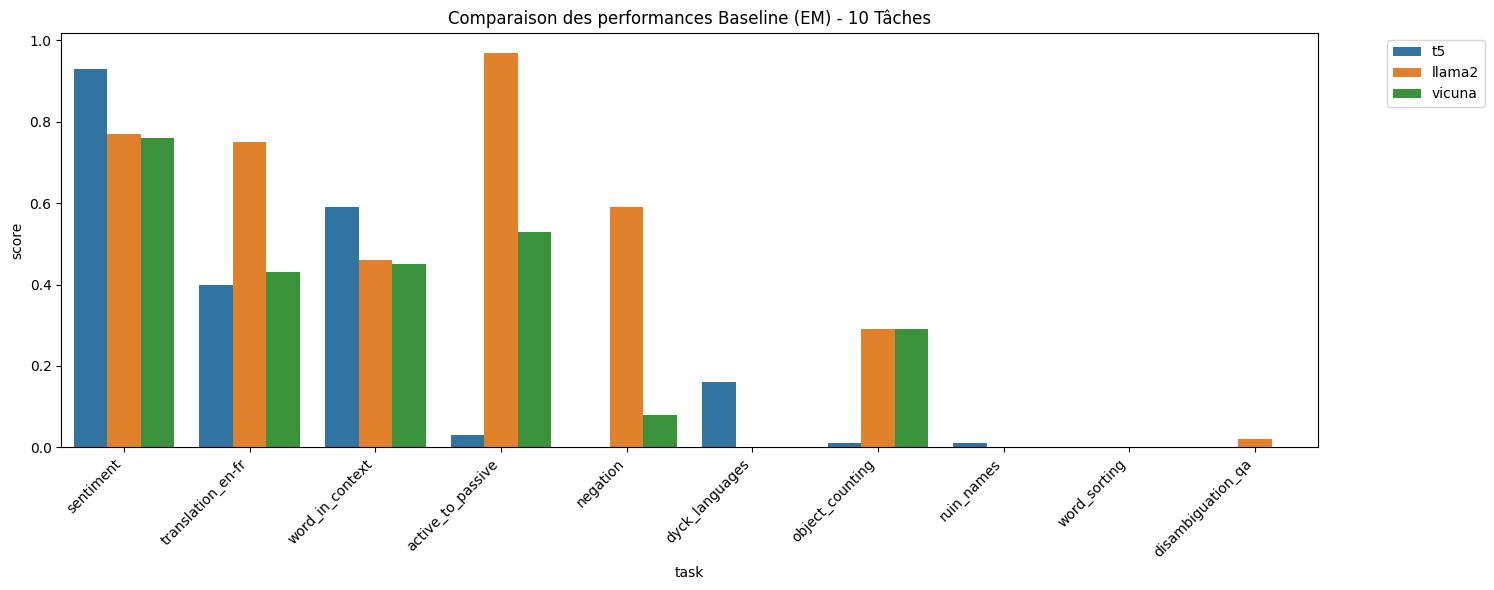

In [ ]:
baseline = df_all[df_all['stimulus'] == '0 (Baseline)']

plt.figure(figsize=(15, 6))
sns.barplot(data=baseline, x='task', y='score', hue='model')
plt.title("Comparaison des performances Baseline (EM) - 10 Tâches")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("comparaison_baselines.png")
plt.show()

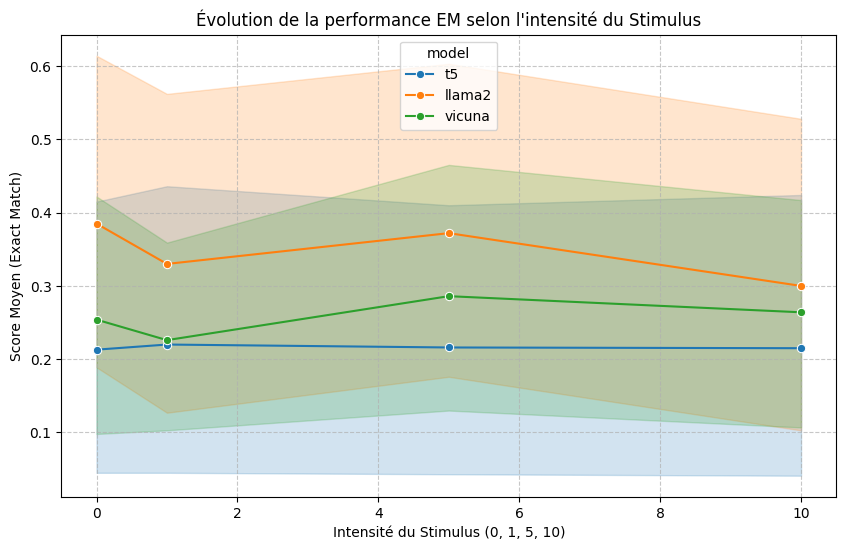

In [ ]:
df_all['stim_val'] = df_all['stimulus'].apply(lambda x: 0 if 'Baseline' in str(x) else int(x))

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='stim_val', y='score', hue='model', marker='o')
plt.title("Évolution de la performance EM selon l'intensité du Stimulus")
plt.xlabel("Intensité du Stimulus (0, 1, 5, 10)")
plt.ylabel("Score Moyen (Exact Match)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("evolution_stimuli_models.png")
plt.show()

--- Comparaison EM vs BLEU (Traduction) ---
                 em_normalized      bleu
model  stimulus                         
llama2 0                  0.00  0.005849
       1                  0.00  0.006629
       5                  0.00  0.005621
       10                 0.00  0.006904
t5     0                  0.22  0.039122
       1                  0.20  0.037061
       5                  0.21  0.038839
       10                 0.21  0.037344
vicuna 0                  0.43  0.078952
       1                  0.35  0.063934
       5                  0.36  0.070010
       10                 0.18  0.038392


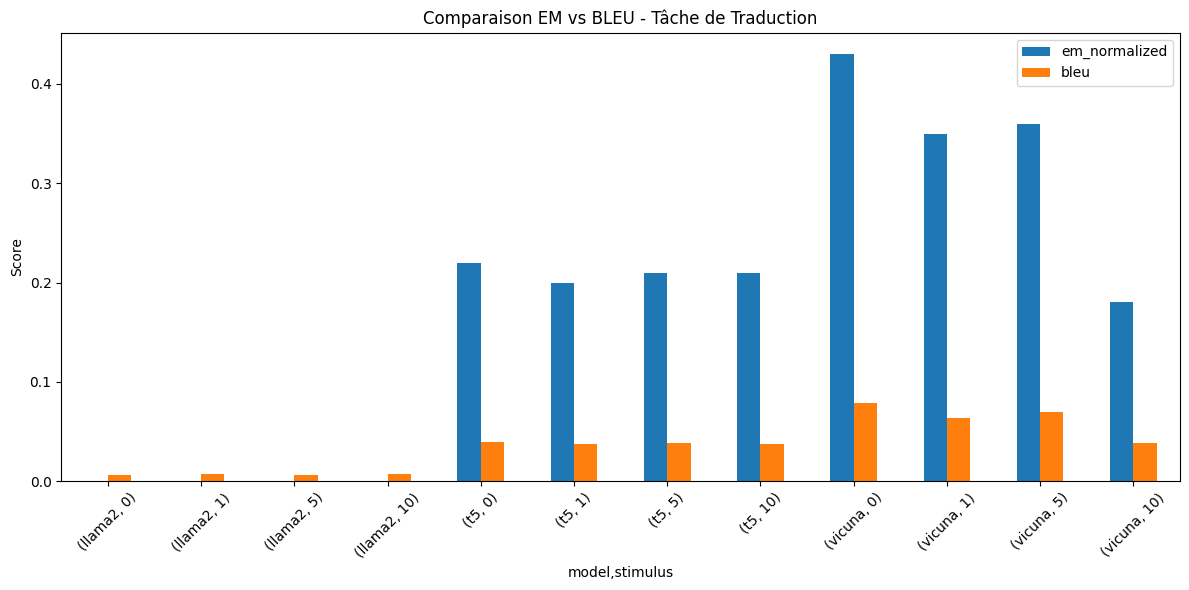

In [ ]:
# Chargement du fichier détaillé
df_bleu = pd.read_csv("/content/NegativePrompt/RESULTS/results_10_tasks/results_bleu_3models_detailed.csv")

# Comparaison EM vs BLEU sur la tâche de traduction
translation_stats = df_bleu[df_bleu['task'] == 'translation_en-fr'].groupby(['model', 'stimulus'])[['em_normalized', 'bleu']].mean()

print("--- Comparaison EM vs BLEU (Traduction) ---")
print(translation_stats)

# Visualisation pour prouver que BLEU est plus "juste"
translation_stats.plot(kind='bar', figsize=(12, 6))
plt.title("Comparaison EM vs BLEU - Tâche de Traduction")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("comparaison_em_bleu.png")
plt.show()

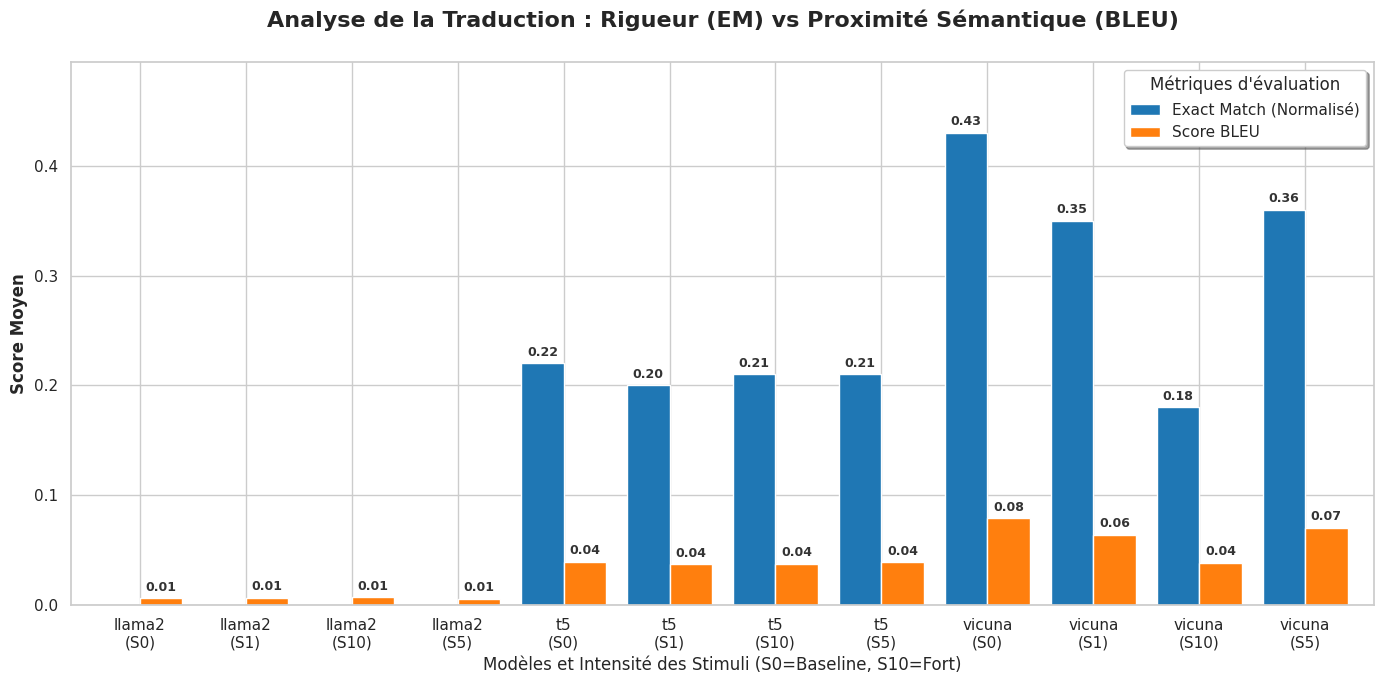

✅ Graphique 'comparaison_em_bleu_final.png' généré avec succès.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Chargement des données
# (Adapte le chemin si nécessaire)
try:
    df_bleu = pd.read_csv("/content/NegativePrompt/RESULTS/results_10_tasks/results_bleu_3models_detailed.csv")
except:
    df_bleu = pd.read_csv("results_bleu_3models_detailed.csv")

# 3. Préparation des données pour la traduction
df_trans = df_bleu[df_bleu['task'] == 'translation_en-fr'].copy()

# Nettoyage des noms de stimuli pour un affichage plus propre (ex: "0 (Baseline)" -> "0")
df_trans['stimulus_label'] = df_trans['stimulus'].apply(lambda x: str(x).split(' ')[0])

# Calcul des moyennes par modèle et stimulus
stats = df_trans.groupby(['model', 'stimulus_label'])[['em_normalized', 'bleu']].mean().reset_index()

# Création d'un label combiné pour l'axe X : "Modèle (S0)"
stats['x_label'] = stats['model'] + "\n(S" + stats['stimulus_label'] + ")"

# 4. Génération du graphique
fig, ax = plt.subplots(figsize=(14, 7))

# Définition explicite des couleurs : EM en bleu, BLEU en orange
# On utilise l'indexation de pandas pour garder les barres groupées par label
stats.set_index('x_label')[['em_normalized', 'bleu']].plot(
    kind='bar',
    ax=ax,
    color=['#1f77b4', '#ff7f0e'], # Bleu et Orange
    width=0.8,
    edgecolor='white',
    linewidth=1
)

# 5. Personnalisation
plt.title("Analyse de la Traduction : Rigueur (EM) vs Proximité Sémantique (BLEU)",
          fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Score Moyen", fontsize=12, fontweight='bold')
plt.xlabel("Modèles et Intensité des Stimuli (S0=Baseline, S10=Fort)", fontsize=12)

# Amélioration de la légende
plt.legend(["Exact Match (Normalisé)", "Score BLEU"],
           title="Métriques d'évaluation",
           frameon=True, shadow=True, loc='upper right')

# Affichage des valeurs sur les barres pour la précision
for p in ax.patches:
    if p.get_height() > 0: # N'affiche que si le score est > 0
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold', color='#333333')

plt.xticks(rotation=0) # Garde les labels horizontaux pour la lisibilité
plt.ylim(0, stats[['em_normalized', 'bleu']].values.max() * 1.15) # Donne de l'espace en haut
plt.tight_layout()

# 6. Sauvegarde
plt.savefig("comparaison_em_bleu_final.png", dpi=300)
plt.show()

print("✅ Graphique 'comparaison_em_bleu_final.png' généré avec succès.")

In [ ]:
# Code pour mesurer si le modèle "répète" le stimulus négatif
distraction_keywords = ["mundane", "boredom", "seen others", "efficiently", "good at this"]

def check_distracted(text):
    if pd.isna(text): return False
    return any(word in str(text).lower() for word in distraction_keywords)

# Utilisation du fichier détaillé (BLEU) pour voir les prédictions réelles
df_bleu['is_distracted'] = df_bleu['prediction'].apply(check_distracted)
distraction_stats = df_bleu.groupby(['model', 'stimulus'])['is_distracted'].mean() * 100

print("--- Pourcentage de réponses 'distraites' par le stimulus ---")
print(distraction_stats)

--- Pourcentage de réponses 'distraites' par le stimulus ---
model   stimulus
llama2  0            0.000000
        1            6.666667
        5            7.333333
        10          18.666667
t5      0            0.000000
        1            0.333333
        5            0.000000
        10           0.333333
vicuna  0            0.000000
        1            8.000000
        5            4.333333
        10           4.666667
Name: is_distracted, dtype: float64


In [ ]:
# Code pour grouper les tâches par famille
task_mapping = {
    'sentiment': 'Sémantique', 'translation_en-fr': 'Sémantique',
    'word_in_context': 'Sémantique', 'active_to_passive': 'Sémantique', 'negation': 'Sémantique',
    'dyck_languages': 'Logique', 'word_sorting': 'Logique',
    'object_counting': 'Raisonnement', 'ruin_names': 'Raisonnement', 'disambiguation_qa': 'Raisonnement'
}
df_all['category'] = df_all['task'].map(task_mapping)

cat_analysis = df_all.groupby(['model', 'stim_val', 'category'])['score'].mean().unstack(level=1)
print("--- Résilience par catégorie de tâches ---")
print(cat_analysis)

KeyError: 'stim_val'

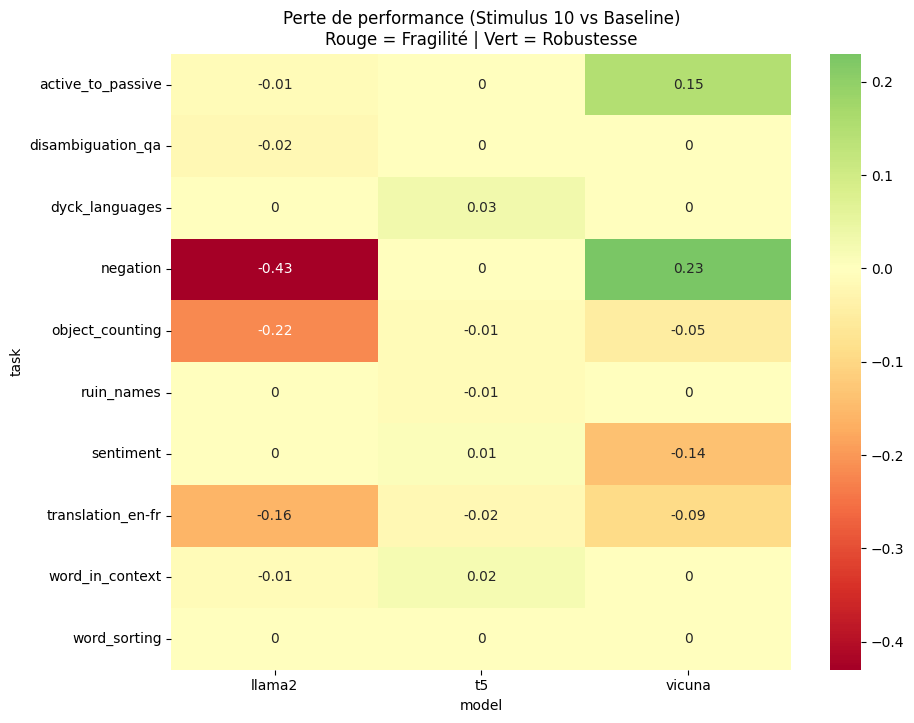

In [ ]:
# Code pour générer la Heatmap de dégradation
pivot_0 = df_all[df_all['stim_val'] == 0].pivot(index='task', columns='model', values='score')
pivot_10 = df_all[df_all['stim_val'] == 10].pivot(index='task', columns='model', values='score')
degradation = pivot_10 - pivot_0

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(degradation, annot=True, cmap="RdYlGn", center=0)
plt.title("Perte de performance (Stimulus 10 vs Baseline)\nRouge = Fragilité | Vert = Robustesse")
plt.savefig("heatmap_fragilite.png")

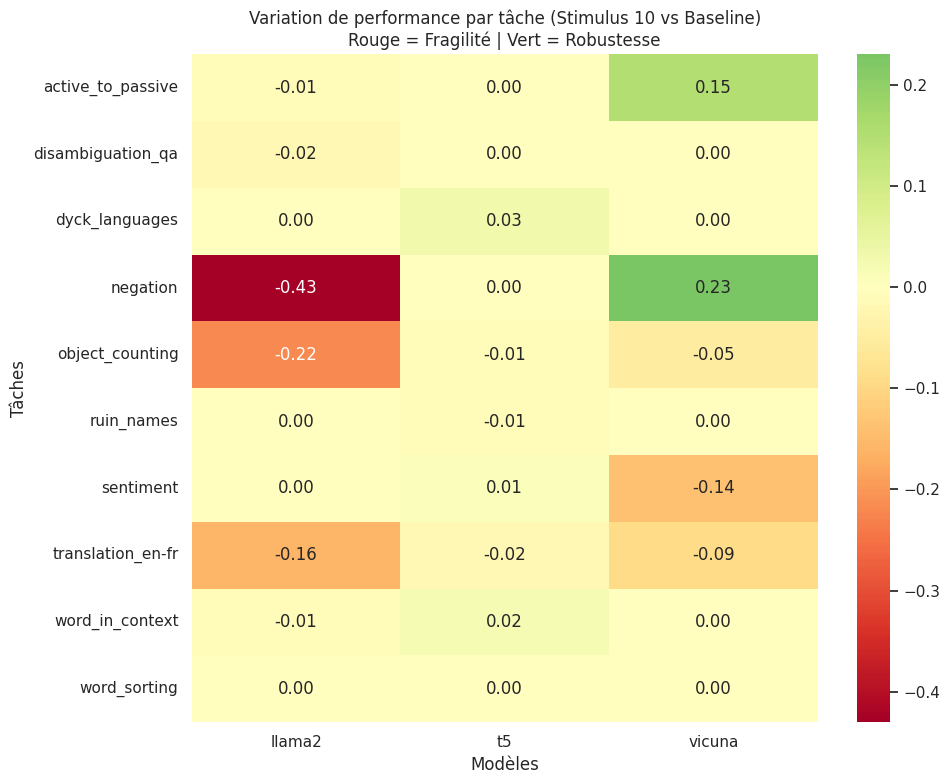

In [ ]:

# 3. Calculer la différence entre Baseline (0) et Stimulus 10
# On pivote pour avoir les tâches en index et les stimuli en colonnes
pivot_df = df_all.pivot_table(index=['model', 'task'], columns='stimulus', values='score')

# Calcul de la variation (S10 - Baseline)
# Note : adapter le nom de la colonne '0 (Baseline)' si nécessaire
baseline_col = '0 (Baseline)'
pivot_df['delta'] = pivot_df['10'] - pivot_df[baseline_col]

# 4. Préparation de la Heatmap
heatmap_data = pivot_df['delta'].unstack(level=0)

# 5. Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Variation de performance par tâche (Stimulus 10 vs Baseline)\nRouge = Fragilité | Vert = Robustesse")
plt.ylabel("Tâches")
plt.xlabel("Modèles")
plt.tight_layout()
plt.savefig("heatmap_variation_taches.png")
plt.show()

In [1]:
!pip install -U peft

In [2]:
# Lance l'entraînement LoRA sur Flan-T5-Large
# Cela va créer un dossier de sauvegarde (ex: ./t5_lora_model)
!python train_t5_lora.py

python3: can't open file '/content/train_t5_lora.py': [Errno 2] No such file or directory


In [3]:
# Compare l'original vs l'amélioré
!python eval_t5_lora.py

python3: can't open file '/content/eval_t5_lora.py': [Errno 2] No such file or directory


In [4]:
%pwd

'/content'

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
%cd /content/NegativePrompt

[Errno 2] No such file or directory: '/content/NegativePrompt'
/content


In [26]:
!ls /content/drive/MyDrive/PPD M2/

ls: cannot access 'M2/': No such file or directory
/content/drive/MyDrive/PPD:
NegativePrompt	PPD-MLSD-FA.xlsx


In [27]:
%cd /content/drive/My Drive/PPD M2/

/content/drive/My Drive/PPD M2


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
%cd "/content/drive/My Drive/PPD M2/"
!ls

/content/drive/My Drive/PPD M2
 ANALYSES.ipynb		    lora_train.jsonl
 build_lora_dataset.py	    lora_val.jsonl
 eval_t5_lora.py	   'ppd_test_VF (6).ipynb'
'Explication SUJET.odt'     Rapport_PPD_M2.docx
 Fiche-Evaluation-PPD.pdf   TEST_AMELIORATION_PPD_.ipynb
 lora_test.jsonl	    train_t5_lora.py


In [30]:
!pip install -U peft bitsandbytes accelerate
!python train_t5_lora.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.7 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/content/drive/MyDrive/PPD M2/train_t5_lora.py", line 18, in <module>
    dataset = load_dataset("json", data_files={
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1392, in load_dataset
    builder_instance = load_dataset_builder(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1132, in load_dataset_builder
    dataset_module = dataset_module_factory(
                     ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 912, in dataset_module_factory
    ).get_module()
      ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 526, in get_module
    data_files = DataFilesDict.from_patterns(
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/

In [31]:
!pip install -U peft bitsandbytes accelerate
!python train_t5_lora.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/PPD M2/train_t5_lora.py", line 18, in <module>
    dataset = load_dataset("json", data_files={
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1392, in load_dataset
    builder_instance = load_dataset_builder(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 1132, in load_dataset_builder
    dataset_module = dataset_module_factory(
                     ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 912, in dataset_module_factory
    ).get_module()
      ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/load.py", line 526, in get_module
    data_files = DataFilesDict.from_patterns(
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/datasets/data_files.py", line 689, in from_

In [32]:
import os

# On définit le chemin vers ton dossier Drive
drive_path = "/content/drive/MyDrive/PPD M2/"

# On lit le script actuel
with open(f"{drive_path}train_t5_lora.py", "r") as f:
    code = f.read()

# On remplace les chemins Kaggle par tes chemins Drive
code = code.replace("/kaggle/working/lora_train.jsonl", f"{drive_path}lora_train.jsonl")
code = code.replace("/kaggle/working/lora_val.jsonl", f"{drive_path}lora_val.jsonl")

# On sauvegarde le script corrigé
with open(f"{drive_path}train_t5_lora_colab.py", "w") as f:
    f.write(code)

print("✅ Script corrigé créé : train_t5_lora_colab.py")

✅ Script corrigé créé : train_t5_lora_colab.py


In [33]:
%cd "/content/drive/MyDrive/PPD M2/"
!python train_t5_lora_colab.py

/content/drive/My Drive/PPD M2
Generating train split: 56688 examples [00:01, 42882.11 examples/s]
config.json: 100% 662/662 [00:00<00:00, 1.42MB/s]
tokenizer_config.json: 2.54kB [00:00, 4.17MB/s]
spiece.model: 100% 792k/792k [00:00<00:00, 991kB/s] 
tokenizer.json: 2.42MB [00:00, 35.3MB/s]
special_tokens_map.json: 2.20kB [00:00, 4.43MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 3.13G/3.13G [00:38<00:00, 82.0MB/s]
Loading weights: 100% 558/558 [00:00<00:00, 783.61it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
generation_config.json: 100% 147/147 [00:00<00:00, 355kB/s]
trainable params: 2,359,296 || all params: 785,509,376 || trainable%: 0.3004
Map: 100% 56688/56688 [00:15<00:00, 3708.16 examples/s]
  0% 0/7086 